# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:
    Dataset yang digunakan adalah "Predict Restaurant Customer Satisfaction Dataset" yang saya dapatkan dari Kaggle.

    **Tujuan**:
    Eksperimen ini bertujuan untuk melakukan analisis data eksploratif (EDA) dan preprocessing data transaksi/kunjungan restoran. Data yang sudah dibersihkan akan digunakan untuk membangun model klasifikasi Machine Learning guna memprediksi kepuasan pelanggan (Customer Satisfaction), sehingga restoran dapat mengambil keputusan yang lebih baik dalam meningkatkan layanannya.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [10]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Ignore warning
import warnings
warnings.filterwarnings('ignore')

print("Library berhasil di-import!")

Library berhasil di-import!


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [11]:
df = pd.read_csv('restaurant_satisfaction_raw.csv')

print(f"Ukuran dataset: {df.shape}")
display(df.head())

Ukuran dataset: (1500, 19)


,CustomerID,Age,Gender,Income,VisitFrequency,AverageSpend,PreferredCuisine,TimeOfVisit,GroupSize,DiningOccasion,MealType,OnlineReservation,DeliveryOrder,LoyaltyProgramMember,WaitTime,ServiceRating,FoodRating,AmbianceRating,HighSatisfaction
0,654,35,Male,83380,Weekly,27.829142,Chinese,Breakfast,3,Business,Takeaway,0,1,1,43.523929,2,5,4,0
1,655,19,Male,43623,Rarely,115.408622,American,Dinner,1,Casual,Dine-in,0,0,0,57.524294,5,5,3,0
2,656,41,Female,83737,Weekly,106.693771,American,Dinner,6,Celebration,Dine-in,0,1,0,48.682623,3,4,5,0
3,657,43,Male,96768,Rarely,43.508508,Indian,Lunch,1,Celebration,Dine-in,0,0,0,7.552993,4,5,1,0
4,658,55,Female,67937,Monthly,148.084627,Chinese,Breakfast,1,Business,Takeaway,0,0,1,37.789041,2,3,5,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            1500 non-null   int64  
 1   Age                   1500 non-null   int64  
 2   Gender                1500 non-null   object 
 3   Income                1500 non-null   int64  
 4   VisitFrequency        1500 non-null   object 
 5   AverageSpend          1500 non-null   float64
 6   PreferredCuisine      1500 non-null   object 
 7   TimeOfVisit           1500 non-null   object 
 8   GroupSize             1500 non-null   int64  
 9   DiningOccasion        1500 non-null   object 
 10  MealType              1500 non-null   object 
 11  OnlineReservation     1500 non-null   int64  
 12  DeliveryOrder         1500 non-null   int64  
 13  LoyaltyProgramMember  1500 non-null   int64  
 14  WaitTime              1500 non-null   float64


,CustomerID,Age,Income,AverageSpend,GroupSize,OnlineReservation,DeliveryOrder,LoyaltyProgramMember,WaitTime,ServiceRating,FoodRating,AmbianceRating,HighSatisfaction
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,1403.500000,43.832000,85921.890000,105.659004,5.035333,0.296667,0.405333,0.480000,30.163550,3.044000,2.997333,2.987333,0.134000
std,433.157015,14.967157,38183.051749,52.381849,2.558864,0.456941,0.491120,0.499766,17.214184,1.423405,1.418920,1.450716,0.340766
min,654.000000,18.000000,20012.000000,10.306127,1.000000,0.000000,0.000000,0.000000,0.001380,1.000000,1.000000,1.000000,0.000000
25%,1028.750000,31.750000,52444.000000,62.287907,3.000000,0.000000,0.000000,0.000000,15.235423,2.000000,2.000000,2.000000,0.000000
50%,1403.500000,44.000000,85811.000000,104.626408,5.000000,0.000000,0.000000,0.000000,30.044055,3.000000,3.000000,3.000000,0.000000
75%,1778.250000,57.000000,119159.250000,148.649330,7.000000,1.000000,1.000000,1.000000,45.285649,4.000000,4.000000,4.000000,0.000000
max,2153.000000,69.000000,149875.000000,199.973527,9.000000,1.000000,1.000000,1.000000,59.970762,5.000000,5.000000,5.000000,1.000000



=== Pengecekan Missing Values ===
CustomerID              0
Age                     0
Gender                  0
Income                  0
VisitFrequency          0
AverageSpend            0
PreferredCuisine        0
TimeOfVisit             0
GroupSize               0
DiningOccasion          0
MealType                0
OnlineReservation       0
DeliveryOrder           0
LoyaltyProgramMember    0
WaitTime                0
ServiceRating           0
FoodRating              0
AmbianceRating          0
HighSatisfaction        0
dtype: int64

=== Proporsi Target (HighSatisfaction) ===
HighSatisfaction
0    0.866
1    0.134
Name: proportion, dtype: float64


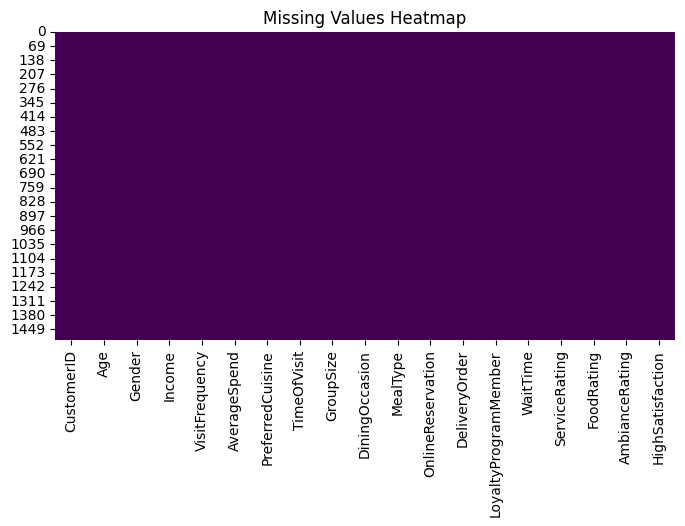

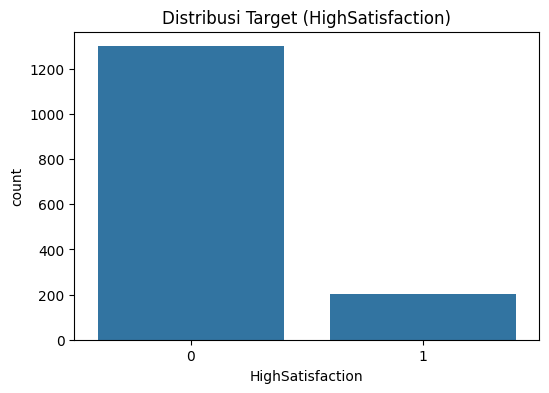

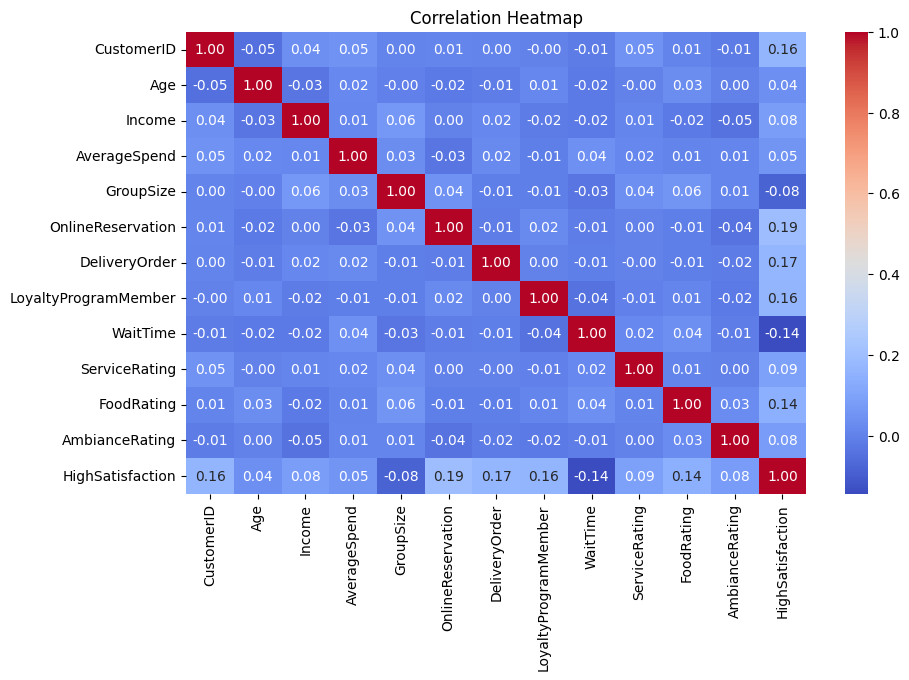

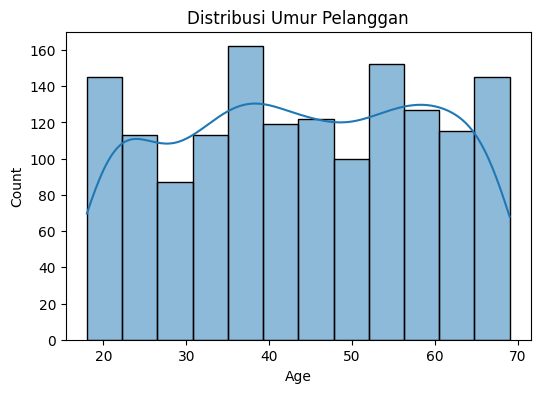

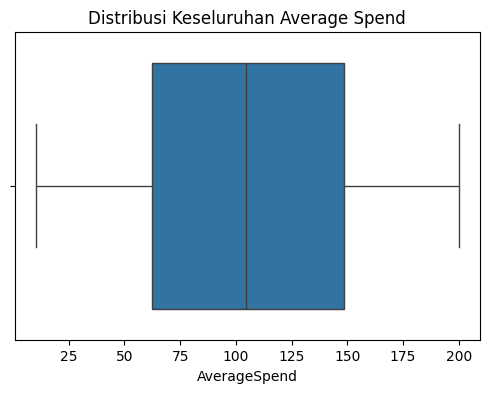

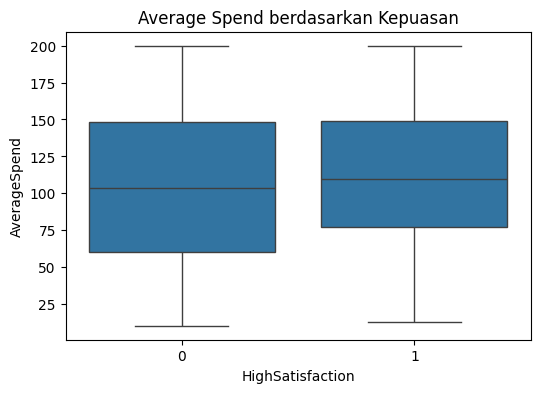

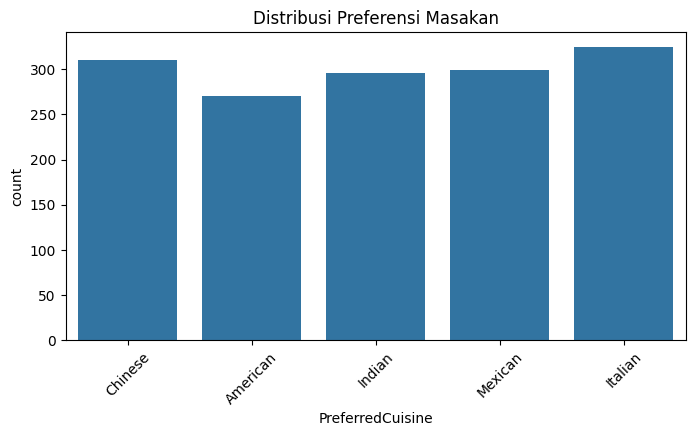

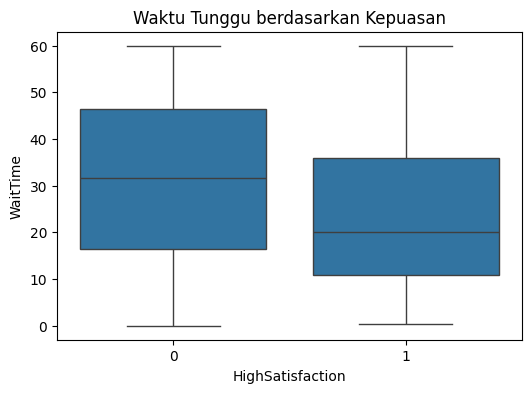

In [12]:
print("=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Deskriptif ===")
display(df.describe())

print("\n=== Pengecekan Missing Values ===")
print(df.isnull().sum())

print("\n=== Proporsi Target (HighSatisfaction) ===")
print(df['HighSatisfaction'].value_counts(normalize=True))

# 1. Visualisasi Missing Values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

# 2. Distribusi Target
plt.figure(figsize=(6, 4))
sns.countplot(x='HighSatisfaction', data=df)
plt.title('Distribusi Target (HighSatisfaction)')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 4. Distribusi Umur Pelanggan
plt.figure(figsize=(6, 4))
sns.histplot(df['Age'], kde=True)
plt.title('Distribusi Umur Pelanggan')
plt.show()

# 5. Boxplot Keseluruhan Average Spend
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['AverageSpend'])
plt.title('Distribusi Keseluruhan Average Spend')
plt.show()

# 6. Boxplot Average Spend vs Target
plt.figure(figsize=(6, 4))
sns.boxplot(x='HighSatisfaction', y='AverageSpend', data=df)
plt.title('Average Spend berdasarkan Kepuasan')
plt.show()

# 7. Distribusi Preferred Cuisine
plt.figure(figsize=(8, 4))
sns.countplot(x='PreferredCuisine', data=df)
plt.title('Distribusi Preferensi Masakan')
plt.xticks(rotation=45)
plt.show()

# 8. Boxplot Wait Time vs Target
plt.figure(figsize=(6, 4))
sns.boxplot(x='HighSatisfaction', y='WaitTime', data=df)
plt.title('Waktu Tunggu berdasarkan Kepuasan')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# Membuat salinan dataset agar data asli tetap aman
df_clean = df.copy()

print("Shape dataset sebelum preprocessing:", df_clean.shape)

# =========================================================
# 1. Menghapus atau Menangani Data Kosong (Missing Values)
# =========================================================
print("\nJumlah missing values sebelum penanganan:", df_clean.isnull().sum().sum())
df_clean = df_clean.dropna()
print("Jumlah missing values setelah penanganan:", df_clean.isnull().sum().sum())

# =========================================================
# 2. Menghapus Data Duplikat
# =========================================================
print("\nJumlah data duplikat sebelum dihapus:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Jumlah data duplikat setelah dihapus:", df_clean.duplicated().sum())

# Menghapus kolom ID karena tidak memiliki nilai prediktif
df_clean.drop('CustomerID', axis=1, inplace=True)

# Membuat fitur baru: rata-rata pengeluaran per orang
df_clean['SpendPerPerson'] = df_clean['AverageSpend'] / df_clean['GroupSize']

# =========================================================
# 4. Deteksi dan Penanganan Outlier
# =========================================================
# Menggunakan metode IQR pada kolom AverageSpend
Q1 = df_clean['AverageSpend'].quantile(0.25)
Q3 = df_clean['AverageSpend'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df_clean[(df_clean['AverageSpend'] < lower_bound) | (df_clean['AverageSpend'] > upper_bound)]
print(f"\nJumlah outlier pada AverageSpend yang dihapus: {len(outliers)}")

# Memfilter data agar hanya menyimpan nilai dalam batas normal
df_clean = df_clean[(df_clean['AverageSpend'] >= lower_bound) & (df_clean['AverageSpend'] <= upper_bound)]

# =========================================================
# 6. Binning (Pengelompokan Data)
# =========================================================
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0, 25, 59, 100],
    labels=['Youth', 'Adult', 'Senior']
)
df_clean.drop('Age', axis=1, inplace=True)

# Persiapan Feature dan Target
X = df_clean.drop('HighSatisfaction', axis=1)
y = df_clean['HighSatisfaction']

# Menentukan Kolom Numerik dan Kategorikal
categorical_cols = [
    'Gender', 'VisitFrequency', 'PreferredCuisine',
    'TimeOfVisit', 'DiningOccasion', 'MealType', 'AgeGroup'
]

numerical_cols = [
    'Income', 'AverageSpend', 'GroupSize', 'WaitTime',
    'ServiceRating', 'FoodRating', 'AmbianceRating',
    'SpendPerPerson', 'OnlineReservation', 'DeliveryOrder', 'LoyaltyProgramMember'
]

# =========================================================
# 3. Normalisasi atau Standarisasi Fitur
# 5. Encoding Data Kategorikal
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Output tetap dataframe Pandas
preprocessor.set_output(transform='pandas')

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n=== Proses Fit & Transform ===")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Shape X_train_processed:", X_train_processed.shape)
print("Shape X_test_processed :", X_test_processed.shape)

# Menyimpan Dataset Hasil Preprocessing
train_final = X_train_processed.copy()
train_final['HighSatisfaction'] = y_train

test_final = X_test_processed.copy()
test_final['HighSatisfaction'] = y_test

# Simpan dataset ke CSV
train_final.to_csv('train_preprocessed.csv', index=False)
test_final.to_csv('test_preprocessed.csv', index=False)

print("\nDataset berhasil disimpan sebagai 'train_preprocessed.csv' dan 'test_preprocessed.csv'.")
display(train_final.head(3))

Shape dataset sebelum preprocessing: (1500, 19)

Jumlah missing values sebelum penanganan: 0
Jumlah missing values setelah penanganan: 0

Jumlah data duplikat sebelum dihapus: 0
Jumlah data duplikat setelah dihapus: 0

Jumlah outlier pada AverageSpend yang dihapus: 0

=== Proses Fit & Transform ===
Shape X_train_processed: (1200, 33)
Shape X_test_processed : (300, 33)

Dataset berhasil disimpan sebagai 'train_preprocessed.csv' dan 'test_preprocessed.csv'.


,num__Income,num__AverageSpend,num__GroupSize,num__WaitTime,num__ServiceRating,num__FoodRating,num__AmbianceRating,num__SpendPerPerson,num__OnlineReservation,num__DeliveryOrder,...,cat__TimeOfVisit_Lunch,cat__DiningOccasion_Business,cat__DiningOccasion_Casual,cat__DiningOccasion_Celebration,cat__MealType_Dine-in,cat__MealType_Takeaway,cat__AgeGroup_Adult,cat__AgeGroup_Senior,cat__AgeGroup_Youth,HighSatisfaction
823,-0.886778,1.196856,-0.019787,-0.216764,0.665269,-0.709170,0.018992,0.052945,1.533609,-0.832181,...,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0
1103,1.252569,-1.074266,-0.019787,-0.406865,-1.435580,-1.415985,0.709593,-0.642551,-0.652057,-0.832181,...,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0
303,1.503234,-1.723101,-0.019787,-1.690269,1.365552,-0.002356,0.709593,-0.841246,-0.652057,1.201662,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0
